# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Shravya Etta

**Date:** 09/09/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.

** QUESTION 2 **

In [5]:
import pandas as pd

df_gift = pd.read_csv("ForeignGifts_edu.csv")
df_gift.head(10)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
5,6,105100,University of Alabama,Tuscaloosa,AL,43501,30231,Contract,KUWAIT,Kuwait-Embassy of the State
6,7,105100,University of Alabama,Tuscaloosa,AL,43507,30162,Contract,KUWAIT,Kuwait-Embassy of the State
7,8,105100,University of Alabama,Tuscaloosa,AL,43517,200,Monetary Gift,GERMANY,"Mercedes-Benz U.S. International, I"
8,9,105100,University of Alabama,Tuscaloosa,AL,43529,5136,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
9,10,105100,University of Alabama,Tuscaloosa,AL,43531,57049,Contract,JAPAN,Kansai Gaidai University (KGU)


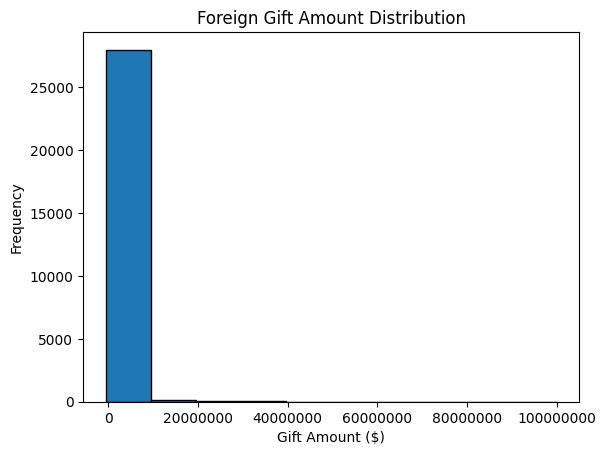

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(df_gift["Foreign Gift Amount"], edgecolor="black")
plt.title("Foreign Gift Amount Distribution")
plt.xlabel("Gift Amount ($)")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x") # don't want to scale down x-axis values
plt.show()

The histogram above depicts that a large proportion of the gifts are valued in the 'lower' range of 0-10 million. There are a lower proportion gifts valued around 20 million dollars and above, and at least one gift valued in the 100 million dollar range. This histogram indicates that, even though the graph is heavily skewed to the right, foreign gifts as a whole have immense financial value.

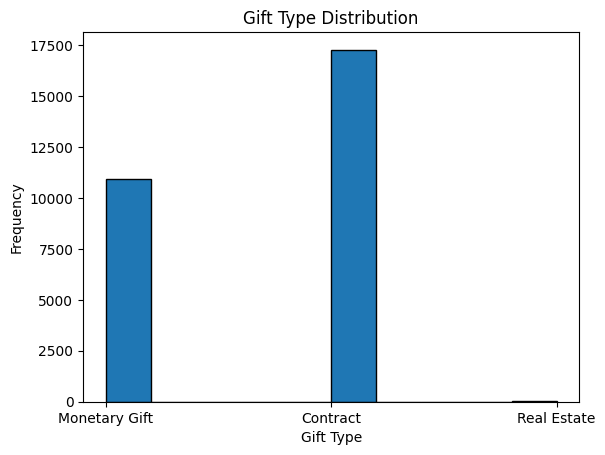

In [7]:
plt.figure()
plt.hist(df_gift["Gift Type"], edgecolor="black")
plt.title("Gift Type Distribution")
plt.xlabel("Gift Type")
plt.ylabel("Frequency")
plt.show()

Contracts and monetary gifts combined account for over 95% of all reported gifts in the dataset. Specifically, contract-type gifts represent ~1.5 times that of monetary-type gifts.

Real estate gifts account for a very small proportion of the dataset, which could be expected since these types of transactions are likely more complicated to file across countries.

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


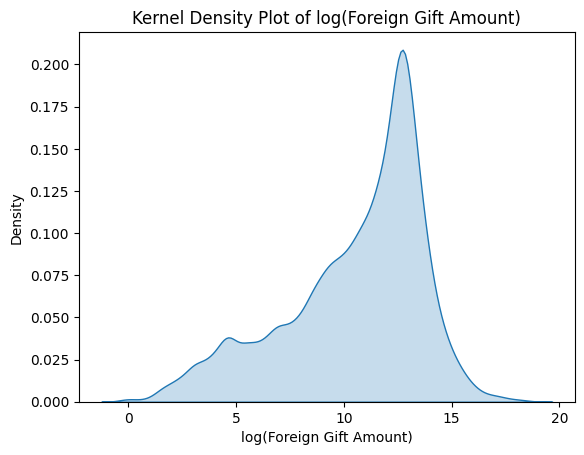

In [14]:
import seaborn as sns

# first density plot
df_gift["log_amount"] = np.log(df_gift["Foreign Gift Amount"])

plt.figure()
sns.kdeplot(df_gift["log_amount"], fill=True)
plt.title("Kernel Density Plot of log(Foreign Gift Amount)")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

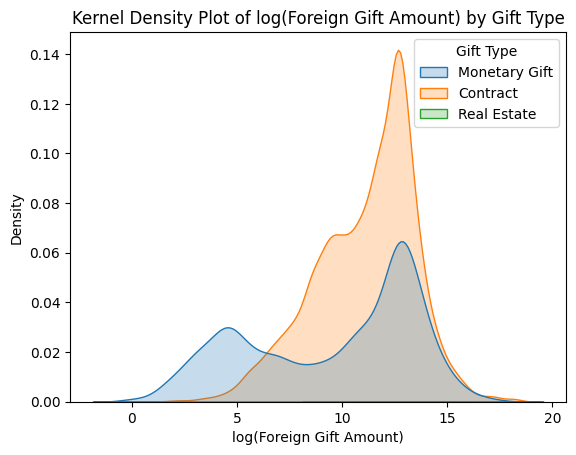

In [22]:
# second density plot; dependent on gift size
plt.figure()
sns.kdeplot(
    data=df_gift,
    x="log_amount",
    hue="Gift Type",
    fill=True
)
plt.title("Kernel Density Plot of log(Foreign Gift Amount) by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

Both the density plots above have a bell-shaped, normal distribution, indicating that log-transforming the variables helped more clearly display their characteristics.

The second plot further bolsters that real-estate gifts have an insignificant contribution to foreign gifts, considering that there were not enough real-estate-type gifts to even be shown on the figure. Within monetary and contract gifts, there is a greater distribution of monteary gifts across lower gift sizes. Contract gifts on the other hand, are more centrally distributed, which could reflect the result of long-term, high value contracts. Additionally, there is a spike in both of the plotted gift types around 12-13 millions of dollars.

In [35]:
top = (
    df_gift.groupby("Country of Giftor")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Number of Gifts") # reformatting + country name
)

top_sum = (
    df_gift.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Total Amount (USD)") # reformatting + country name
)

print(f"Top 15 Countries by # of Gifts\n\n", top.to_string(index=False))
print(f"\n\nTop 15 Countries by Amount Gifted (USD)\n\n", top_sum.to_string(index=False))

Top 15 Countries by # of Gifts

 Country of Giftor  Number of Gifts
          ENGLAND             3655
            CHINA             2461
           CANADA             2344
            JAPAN             1896
      SWITZERLAND             1676
     SAUDI ARABIA             1610
           FRANCE             1437
          GERMANY             1394
        HONG KONG             1080
      SOUTH KOREA              811
            QATAR              693
  THE NETHERLANDS              512
            KOREA              452
            INDIA              434
           TAIWAN              381


Top 15 Countries by Amount Gifted (USD)

    Country of Giftor  Total Amount (USD)
               QATAR          2706240869
             ENGLAND          1464906771
               CHINA          1237952112
        SAUDI ARABIA          1065205930
             BERMUDA           899593972
              CANADA           898160656
           HONG KONG           887402529
               JAPAN           6559

The top 15 countries in terms of gift quantity and gift value (USD) are both shown above.

In [37]:
# Group by Giftor Name, sum total amount, and sort
top_giftors = (
    df_gift.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="Total Amount (USD)")
)

print(f"Top 15 Foreign Giftors by Total Amount\n\n", top_giftors.to_string(index=False))
#print(top_giftors.to_string(index=False, formatters={"Total Contribution (USD)": "${:,.2f}".format}))

Top 15 Foreign Giftors by Total Amount

                         Giftor Name  Total Amount (USD)
                   Qatar Foundation          1166503744
Qatar Foundation/Qatar National Res           796197000
     Qatar Foundation for Education           373945215
                          Anonymous           338793629
     Saudi Arabian Cultural Mission           275221475
                                HCL           190000000
      Church of Jesus Christ of LDS           185203715
 Emirates Institute for Advanced Sc           170641244
                                QIC           148355497
                       Anonymous #9            96334996
       Qatar National Research Fund            79021705
         Government of Saudi Arabia            75192434
                  Contracting Party            69996984
                    CMKL University            67700000
      Royal Embassy of Saudi Arabia            67062486


All three of the top giftors in terms of gift value (USD) are Qatar-based organizations.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]